In [1]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [2]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder_behav)

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from utils import get_decoding_info
from tqdm.contrib.itertools import product

subjects = df.reset_index()['subject'].unique()
sessions = [1, 2]
n_voxels_s = [100, 250]
pred = []
for (sub, session, n_voxels) in product(subjects, sessions,n_voxels_s):
    #print(sub, session)
    pred.append(get_decoding_info(sub, session,bids_folder=bids_folder, n_voxels=n_voxels))

pred = pd.concat(pred)

 18%|█▊        | 35/200 [00:01<00:05, 30.09it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise.250voxels/sub-12/func/sub-12_ses-2_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise.250voxels/sub-13/func/sub-13_ses-2_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv


 30%|██▉       | 59/200 [00:02<00:05, 25.79it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise.250voxels/sub-19/func/sub-19_ses-2_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv


 33%|███▎      | 66/200 [00:02<00:05, 23.38it/s]

...

 92%|█████████▏| 184/200 [00:08<00:00, 22.08it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise.250voxels/sub-54/func/sub-54_ses-2_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv


 96%|█████████▋| 193/200 [00:09<00:00, 24.51it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise.250voxels/sub-58/func/sub-58_ses-1_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise.250voxels/sub-58/func/sub-58_ses-2_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv


100%|██████████| 200/200 [00:09<00:00, 20.91it/s]


In [28]:
temp = pred.join(df, how='inner')
temp = temp.drop('session', axis=1)
temp

E        sd        rt  \
subject trial_nr session mask  n_voxels run                                 
1       1        1       NPC_R 100      1    3.200873  0.155523  0.476974   
                                        1    3.200873  0.155523  1.843622   
                               250      1    2.505134  0.683273  0.476974   
                                        1    2.505134  0.683273  1.843622   
                 2       NPC_R 100      1    2.791255  0.468582  0.476974   
...                                               ...       ...       ...   
61      120      1       NPC_R 250      6    3.169934  0.242758  0.989251   
                 2       NPC_R 100      6    2.078880  0.401937  2.106819   
                                        6    2.078880  0.401937  0.989251   
                               250      6    1.867917  0.058799  2.106819   
                                        6    1.867917  0.058799  0.989251   

                                               n1    n2  prob1  prob2  choice  \
subject trial_nr session mask  n_voxels run                                     
1       1        1       NPC_R 100      1    13.0  10.0   0.55   1.00    True   
                                        1    28.0  32.0   1.00   0.55   False   
                               250      1    13.0  10.0   0.55   1.00    True   
                                        1    28.0  32.0   1.00   0.55   False   
                 2       NPC_R 100      1    13.0  10.0   0.55   1.00    True   
...                                           ...   ...    ...    ...     ...   
61      120      1       NPC_R 250      6    42.0  28.0   0.55   1.00    True   
                 2       NPC_R 100      6     7.0  15.0   1.00   0.55    True   
                                        6    42.0  28.0   0.55   1.00    True   
                               250      6     7.0  15.0   1.00   0.55    True   
                                        6    42.0  28.0   0.55   1.00    True   

                                             risky_first  chose_risky  \
subject trial_nr session mask  n_voxels run                             
1       1        1       NPC_R 100      1           True        False   
                                        1          False        False   
                               250      1           True        False   
                                        1          False        False   
                 2       NPC_R 100      1           True        False   
...                                                  ...          ...   
61      120      1       NPC_R 250      6           True        False   
                 2       NPC_R 100      6          False         True   
                                        6           True        False   
                               250      6          False         True   
                                        6           True        False   

                                             n_risky  n_safe      frac  \
subject trial_nr session mask  n_voxels run                              
1       1        1       NPC_R 100      1       13.0    10.0  1.300000   
                                        1       32.0    28.0  1.142857   
                               250      1       13.0    10.0  1.300000   
                                        1       32.0    28.0  1.142857   
                 2       NPC_R 100      1       13.0    10.0  1.300000   
...                                              ...     ...       ...   
61      120      1       NPC_R 250      6       42.0    28.0  1.500000   
                 2       NPC_R 100      6       15.0     7.0  2.142857   
                                        6       42.0    28.0  1.500000   
                               250      6       15.0     7.0  2.142857   
                                        6       42.0    28.0  1.500000   

                                             log(risky/safe)   log(n1)  \
subject t

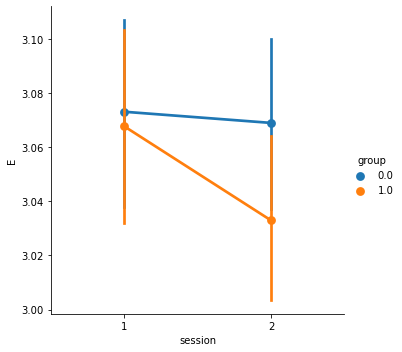

In [29]:
import seaborn as sns

temp = temp.xs(100, axis=0, level=4) # mutlindex in rows(=0) with level (=4 = n_voxels) that match '100'

mean_E = temp.groupby(['subject', 'group', 'session'])[['E']].mean()
sns.catplot(data=mean_E.reset_index(), x='session', hue='group', y='E',kind='point')
